In [1]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

#Imported for categorization of the Sources
from scipy import stats
import astropy.stats as ast
from astropy.visualization import hist
import urllib.request
import lmfit
from importlib import reload

# Get the absolute path to the directory you want to import from
folder_path = os.path.abspath('PythonFiles')

# Insert the path into the system path list
sys.path.insert(0, folder_path)


# Import from BB analysis github
import LC
from LC_Set import LC_Set
#from fermi_catalog import select_bll, select_fsrq, select_bcu

from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import curve_fit
from scipy.interpolate import SmoothBivariateSpline
import astropy.units as u

import download
import pyLCR


The Fermi-LAT Light Curve Repository Toolkit v0.1.0
Support Contact: Daniel Kocevski (daniel.kocevski@nasa.gov)


In [2]:
Names = pd.read_csv('PythonFiles/NameCSV')
Names['Name'][0]

'4FGL J0044.2-8424'

In [3]:
data=pyLCR.getLightCurve('4FGL J0044.2-8424',cadence='weekly',flux_type='photon',index_type='fixed',ts_min=4)


Done.


In [4]:



# look at last MET value of source from LCR.
# if MET_LCR > MET_OLD:
# run analysis
# MET_OLD = MET_LCR
# else:
# continue


# SOURCEMET = np.array([Names['Name'],np.zeros(len(Names['Name']))])
# SOURCEMET = pd.DataFrame({'Name':Names['Name'],'LastMET':np.zeros(len(Names['Name']))})

# SOURCEMET.to_csv('SourceNamesMET',index=False)

SOURCEMET = pd.read_csv('SourceNamesMET').reset_index(drop=True)
SOURCEMET



,Name,LastMET
0,4FGL J0044.2-8424,0.0
1,4FGL J0224.2+0700,0.0
2,4FGL J0227.2+3928,0.0
3,4FGL J0625.8-5441,0.0
4,4FGL J0836.2+2141,0.0
5,4FGL J0920.3-0443,0.0
6,4FGL J1248.9+4840,0.0
7,4FGL J1615.6+2130,0.0
8,4FGL J1814.4+2953,0.0
9,4FGL J2143.5+1743,0.0


In [5]:
for sourcename in SOURCEMET['Name']:
    lightcurve = pyLCR.getLightCurve(sourcename,cadence='weekly',flux_type='photon',index_type='fixed',ts_min=4)
    print('comparing value of', sourcename)
    print(SOURCEMET[SOURCEMET['Name']==sourcename]['LastMET'])
    oldvalue = SOURCEMET.loc[SOURCEMET['Name'] == sourcename, 'LastMET'].item()
    newvalue = lightcurve.met[-1]
    if newvalue>oldvalue:
        print('greater')
    else:
        continue


Done.
comparing value of 4FGL J0044.2-8424
0    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J0224.2+0700
1    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J0227.2+3928
2    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J0625.8-5441
3    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J0836.2+2141
4    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J0920.3-0443
5    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J1248.9+4840
6    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J1615.6+2130
7    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J1814.4+2953
8    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J2143.5+1743
9    0.0
Name: LastMET, dtype: float64
greater

Done.
comparing value of 4FGL J2211.2-1325
10    0.0
Name: LastMET, dtype: float64
greate

In [12]:
data.met

array([2.39889601e+08, 2.40494401e+08, 2.41099201e+08, 2.41704001e+08,
       2.42308801e+08, 2.42913601e+08, 2.43518401e+08, 2.44123201e+08,
       2.44728001e+08, 2.45332801e+08, 2.45937601e+08, 2.46542401e+08,
       2.47147201e+08, 2.47752001e+08, 2.48356801e+08, 2.48961601e+08,
       2.49566401e+08, 2.50171201e+08, 2.50776001e+08, 2.51380801e+08,
       2.51985601e+08, 2.52590401e+08, 2.53195201e+08, 2.53800001e+08,
       2.54404801e+08, 2.55009601e+08, 2.55614401e+08, 2.56219201e+08,
       2.56824001e+08, 2.57428801e+08, 2.58033601e+08, 2.58638401e+08,
       2.59243201e+08, 2.59848001e+08, 2.60452801e+08, 2.61057601e+08,
       2.61662401e+08, 2.62267201e+08, 2.62872001e+08, 2.63476801e+08,
       2.64081601e+08, 2.64686401e+08, 2.65291201e+08, 2.65896001e+08,
       2.66500801e+08, 2.67105601e+08, 2.67710401e+08, 2.68315201e+08,
       2.68920001e+08, 2.69524801e+08, 2.70129601e+08, 2.70734401e+08,
       2.71339201e+08, 2.71944001e+08, 2.72548801e+08, 2.73153601e+08,
      

In [10]:
df1 = pd.DataFrame([test.met_upperlimits,test.flux_upper_limits]).T
df2 = pd.DataFrame([test.met_detections,test.flux]).T

merged = pd.concat([df1,df2],axis=0,ignore_index=True)
merged

NameError: name 'test' is not defined

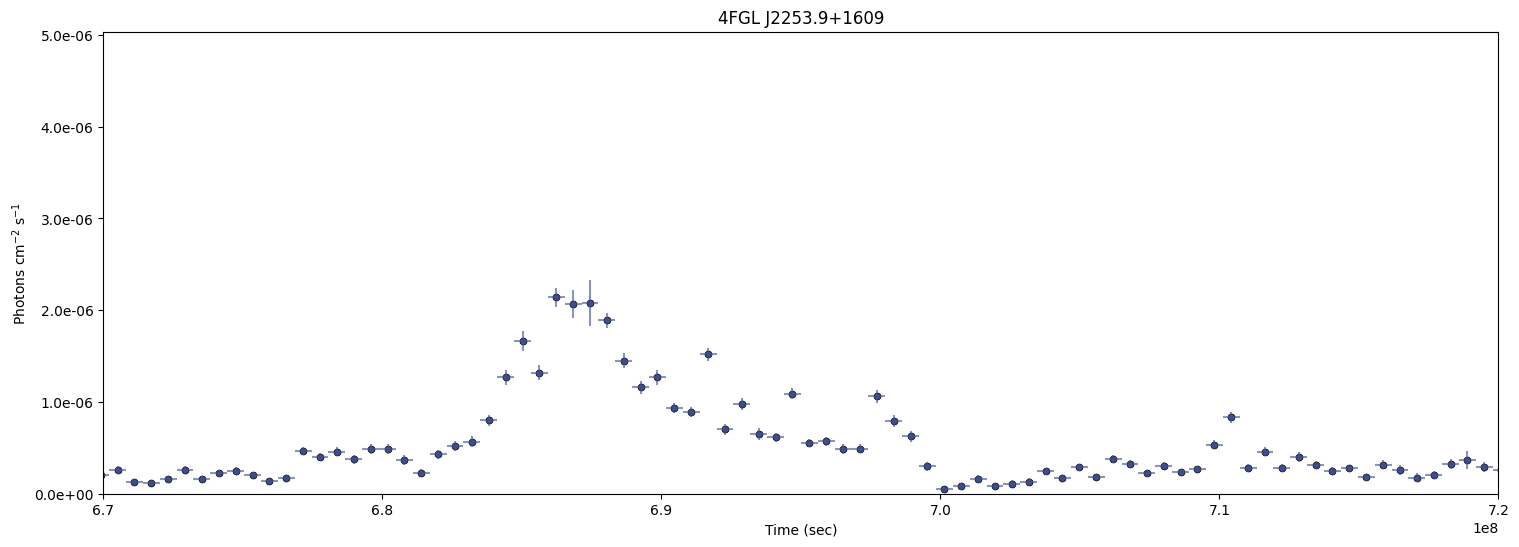

(<Figure size 1800x600 with 1 Axes>,
 <Axes: title={'center': '4FGL J2253.9+1609'}, xlabel='Time (sec)', ylabel='Photons cm$^{-2}$ s$^{-1}$'>)

In [64]:
#data=pyLCR.getLightCurve('4FGL J2253.9+1609',cadence='weekly',flux_type='photon',index_type='fixed',ts_min=4)
data
pyLCR.plotLightCurve(data,xmin=6.7e8,xmax=7.2e8)

In [68]:
data_df = pd.DataFrame({'met':data.met_detections,'flux':data.flux})
data_df = data_df[(data_df['met']>6.7e8) & (data_df['met']<7.2e8)]
data_df['met'].iloc[0]-data_df['met'].iloc[1]

np.float64(-604800.0)

In [6]:
def METcheck(sourcename,oldMET,currentMET):
    if np.abs(oldMET - currentMET) > 604800:
        data = pyLCR.getLightCurve(sourcename,cadence='weekly',flux_type='photon',index_type='fixed',ts_min=4)
        print(sourcename, 'is being updated.')
        SOURCEMET.loc[SOURCEMET['Name']==sourcename,'LastMET']=currentMET
        return data
    else:
        print(sourcename, 'is already up to date.')
        return None
    
METcheck('4FGL J2253.9+1609',SOURCEMET.loc[SOURCEMET['Name']==sourcename,'LastMET'].item(),pyLCR.getCurrentMET())


Done.
4FGL J2253.9+1609 is being updated.


In [7]:
lastCurrentMET = pyLCR.getCurrentMET()
for sourcename in SOURCEMET['Name']:
    METcheck(sourcename,SOURCEMET.loc[SOURCEMET['Name']==sourcename,'LastMET'].item(),lastCurrentMET)


Done.
4FGL J0044.2-8424 is being updated.

Done.
4FGL J0224.2+0700 is being updated.

Done.
4FGL J0227.2+3928 is being updated.

Done.
4FGL J0625.8-5441 is being updated.

Done.
4FGL J0836.2+2141 is being updated.

Done.
4FGL J0920.3-0443 is being updated.

Done.
4FGL J1248.9+4840 is being updated.

Done.
4FGL J1615.6+2130 is being updated.

Done.
4FGL J1814.4+2953 is being updated.

Done.
4FGL J2143.5+1743 is being updated.

Done.
4FGL J2211.2-1325 is being updated.

Done.
4FGL J0538.8-4405 is being updated.

Done.
4FGL J1800.6+7828 is being updated.
4FGL J2253.9+1609 is already up to date.

Done.
4FGL J2229.7-0832 is being updated.

Done.
4FGL J2147.3-7536 is being updated.

Done.
4FGL J1642.9+3948 is being updated.

Done.
4FGL J1626.0-2950 is being updated.

Done.
4FGL J1512.8-0906 is being updated.

Done.
4FGL J1256.1-0547 is being updated.

Done.
4FGL J1229.0+0202 is being updated.

Done.
4FGL J1224.9+2122 is being updated.

Done.
4FGL J1153.4+4931 is being updated.

Done.
4FGL J

In [8]:
SOURCEMET

,Name,LastMET
0,4FGL J0044.2-8424,800023697.0
1,4FGL J0224.2+0700,800023697.0
2,4FGL J0227.2+3928,800023697.0
3,4FGL J0625.8-5441,800023697.0
4,4FGL J0836.2+2141,800023697.0
5,4FGL J0920.3-0443,800023697.0
6,4FGL J1248.9+4840,800023697.0
7,4FGL J1615.6+2130,800023697.0
8,4FGL J1814.4+2953,800023697.0
9,4FGL J2143.5+1743,800023697.0


In [84]:
data.met[-1]-lastCurrentMET

np.float64(-511329.0)

In [86]:
lastCurrentMET % 604800

295330.0

In [90]:
data.met[-4] % 604800

np.float64(388801.0)

In [9]:
pyLCR.computeMJD(data.met[0])

pyLCR.computeMJD(388801.0)

51914.50001157408